In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [52]:
df = pd.read_csv('Social_Network_Ads.csv')

In [53]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [54]:
df.tail()

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [55]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(33)

In [57]:
df[df.duplicated()]

,Age,EstimatedSalary,Purchased
23,45,22000,1
54,27,58000,0
74,32,18000,0
86,24,55000,0
94,29,83000,0
138,28,59000,0
150,26,15000,0
186,20,82000,0
192,29,43000,0
195,34,43000,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


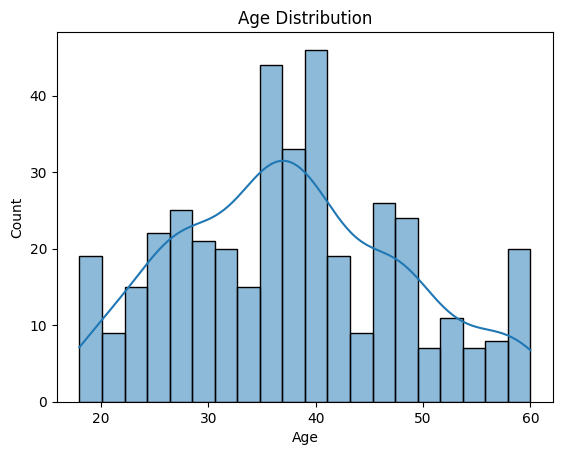

In [59]:
sns.histplot( df["Age"], bins = 20, kde = True )

plt.title("Age Distribution")
plt.show()

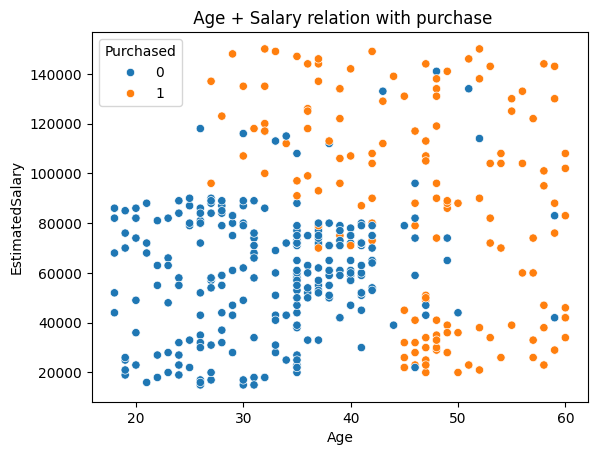

In [60]:
# Scatter Plot (Age + Salary relation with purchase)

sns.scatterplot( x = 'Age', y  ='EstimatedSalary', hue = 'Purchased', data = df)
plt.title( ' Age + Salary relation with purchase' )
plt.show()

In [61]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

<Axes: xlabel='Purchased', ylabel='Age'>

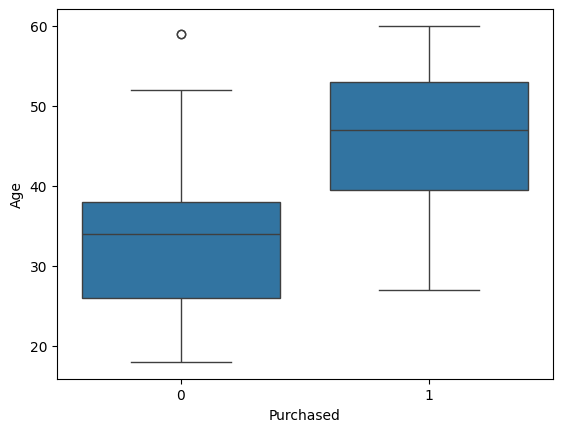

In [62]:
sns.boxplot(x='Purchased', y='Age', data=df)

<Axes: xlabel='Purchased', ylabel='EstimatedSalary'>

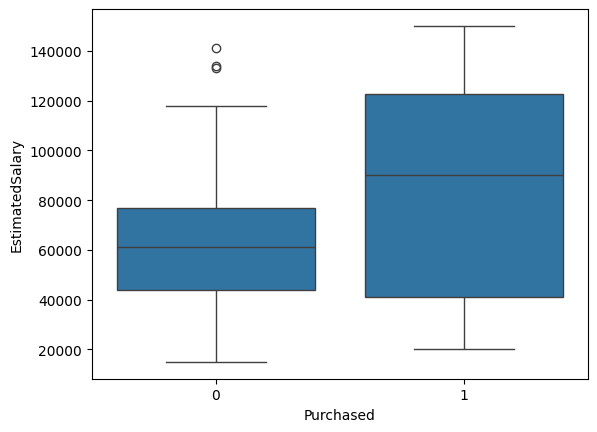

In [63]:
sns.boxplot(x = 'Purchased', y='EstimatedSalary', data = df)

In [64]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [65]:
x = df.drop('Purchased', axis = 1)
y = df['Purchased']

In [66]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.20, random_state = 42)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [71]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [72]:
y_pred = knn.predict(x_test_scaled)

In [73]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9125
[[48  4]
 [ 3 25]]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80



### Observations (K = 5)

* The KNN model with **K = 5** achieved an accuracy of around **90%**, indicating good initial classification performance.
* The confusion matrix shows that the model correctly classified most customer purchase outcomes with relatively few incorrect predictions.
* The classification report indicates that the model provides a reasonable balance between precision, recall, and F1-score for both classes.
* This K = 5 model is considered the **baseline model** before performing cross-validation to identify the optimal K value.


In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Test k values from 1 to 20

k_range = range(1,21)
cv_score = []

# Perform 5-fold cross-validation for each K

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    score = cross_val_score(knn, x_train_scaled, y_train, cv=5, scoring = 'accuracy')
    cv_score.append(score.mean())

# Find best K value

best_k = k_range[np.argmax(cv_score)]
print("Best K:", best_k)
print("Best Cross-Validation Accuracy:", max(cv_score))
    


Best K: 9
Best Cross-Validation Accuracy: 0.90625


### Observations (Hyperparameter Tuning - Best K Selection)

* Cross-validation was performed to identify the optimal value of **K** for the KNN model.
* The best value of **K was found to be 9**, with a cross-validation accuracy of approximately **90.6%**.
* Compared to the baseline model (K = 5), the tuned model showed improved generalization by selecting a more suitable number of neighbors.
* The selected K = 9 was used to train the final KNN model for further evaluation.


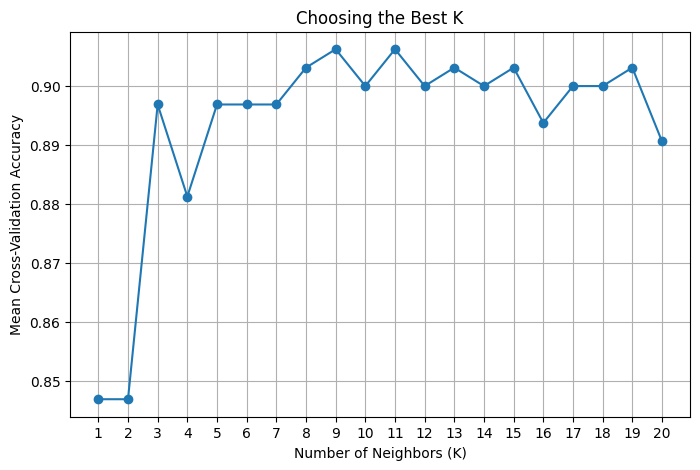

In [79]:
plt.figure(figsize=(8,5))
plt.plot(k_range, cv_score, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Choosing the Best K")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [75]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 9)
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=9)

In [76]:
y_pred = knn.predict(x_test_scaled)

In [80]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9375
[[48  4]
 [ 1 27]]
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        52
           1       0.87      0.96      0.92        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



### Observations (K = 9)

* The KNN model with **K = 9** achieved an accuracy of **93.75%**, showing improved performance compared to the baseline model (K = 5).
* The confusion matrix indicates that the model correctly classified **48 out of 52 non-purchase cases** and **27 out of 28 purchase cases**, with only a few misclassifications.
* The model achieved a high **recall of 96% for class 1**, meaning it successfully identified most customers who are likely to purchase the product.
* The precision and F1-score values indicate a good balance between correctly identifying purchase cases and minimizing incorrect predictions.
* Overall, **K = 9 provided better generalization performance and was selected as the final KNN model.**


AUC Score: 0.9684065934065934


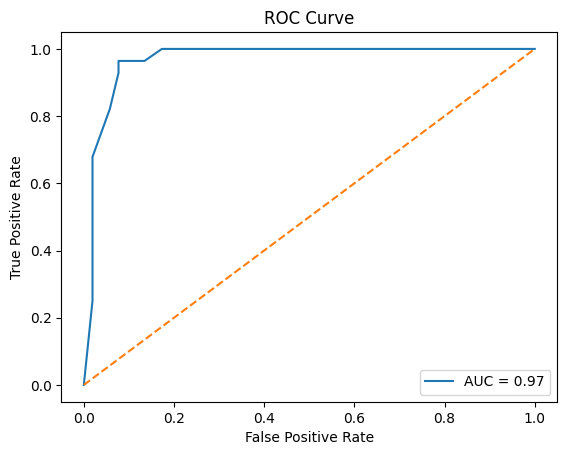

In [84]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = knn.predict_proba(x_test_scaled)[:,1]

# Calculate ROC curve
fpr, tpr, thresholds, = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score( y_test, y_prob)

print("AUC Score:", auc)

# Plot ROC Curve

plt.plot( fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### Observations (ROC-AUC Evaluation)

* The KNN model achieved an **ROC-AUC score of 0.968**, indicating excellent ability to distinguish between customers who purchased and those who did not.
* The high AUC value shows that the model has a strong capability to rank positive and negative classes correctly across different classification thresholds.
* The ROC curve being closer to the **top-left corner** indicates a high True Positive Rate and a relatively low False Positive Rate.
* This confirms that the tuned KNN model (K = 9) performs well in separating purchase and non-purchase customers.


In [85]:
new_customer = pd.DataFrame(
    {
        'Age': [35],
        'EstimatedSalary' : [60000]

    }
)

new_customer

,Age,EstimatedSalary
0,35,60000


Now lets test the model with the new data

In [86]:
new_customer_scaled = scaler.transform(new_customer)

In [87]:
new_cus_pred = knn.predict(new_customer_scaled)

new_cus_pred

array([0])

In [89]:
if new_cus_pred[0] == 1:
    print("Customer is likely to purchase")
else:
    print("Customer is unlikely to purchase")

Customer is unlikely to purchase


In [90]:
# Multiple new customers
new_customers = pd.DataFrame({
    'Age': [25, 35, 45, 30, 50],
    'EstimatedSalary': [30000, 60000, 90000, 50000, 120000]
})

new_customer_scaled = scaler.transform(new_customers)

new_customer_scaled

array([[-1.26299321, -1.17175979],
       [-0.28178945, -0.29907601],
       [ 0.6994143 ,  0.57360778],
       [-0.77239133, -0.5899706 ],
       [ 1.19001618,  1.44629156]])

In [96]:
predictions = knn.predict(new_customer_scaled)

predictions

array([0, 0, 1, 0, 1])